STARTING POINT


Load Cleaned Data

In this step, we load cleaned SACCO financial data.

The data has been standardized into a consistent format:
- Account_Name
- Financial values across years

This ensures consistency and simplifies further analysis.

In [1]:
import pandas as pd
import glob

files = glob.glob("data_clean/*.csv")

df_list = []

for file in files:
    df = pd.read_csv(file)
    df_list.append(df)

len(df_list)

52

Combine Cleaned Datasets

After loading all cleaned SACCO datasets, the next step is to combine them into a single dataset.

Each file represents financial data from a different SACCO but follows the same standardized structure:
- Account_Name
- Financial values across years (2019–2022)

By concatenating these datasets:
- We create a unified dataset for analysis
- Enable comparison across multiple SACCOs
- Prepare the data for transformation and modeling

This step ensures that all SACCO data is consolidated into one dataframe for further processing.

In [2]:
df_all = pd.concat(df_list)

df_all.head()

,Account_Name,2019,2020,2021,2022,2012,2013,2014,2015,2016,...,Unnamed: 16375,Unnamed: 16376,Unnamed: 16377,Unnamed: 16378,Unnamed: 16379,Unnamed: 16380,Unnamed: 16381,Unnamed: 16382,Unnamed: 16383,Unnamed: 12
0,Total Assets,269371213.0,2.934117e+08,369437115.0,403387182.7,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Total Deposit liabilities,221613427.0,2.577053e+08,296337292.0,320546208.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Total Equity,33585269.0,3.528895e+07,53706746.0,63405036.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Total Liabilities,235786131.0,2.581184e+08,315730368.0,339982145.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Cash & Cash Equivalent,10834463.0,6.094258e+07,56687339.0,77254741.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Handling Missing Values

Some financial values were recorded as zeros but represented missing data.

To address this:
- Data was cleaned to ensure proper numeric formatting
- Columns were converted to numeric format in Python
- Zero values were replaced with missing values (NaN)

This ensures accurate representation of financial data and prevents misleading analysis.

In [3]:
df_all.iloc[:, 1:] = df_all.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

C:\Users\morin\AppData\Local\Temp\ipykernel_20204\2289449922.py:1: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  df_all.iloc[:, 1:] = df_all.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')


In [4]:
df_all.iloc[:, 1:] = df_all.iloc[:, 1:].mask(df_all.iloc[:, 1:] == 0)

Reshape Data for Analysis

The combined dataset is currently in a wide format, where each year is represented as a separate column.

To prepare the data for analysis and modeling, we reshape it into a long format. This transformation:
- Converts year columns into a single variable
- Creates a consistent structure for time-based analysis
- Simplifies further feature engineering and modeling

The resulting dataset will contain:
- Account_Name
- Year
- Value

In [5]:
df_long = df_all.melt(
    id_vars=['Account_Name'],
    var_name='Year',
    value_name='Value'
)

df_long.head()

,Account_Name,Year,Value
0,Total Assets,2019,269371213.0
1,Total Deposit liabilities,2019,221613427.0
2,Total Equity,2019,33585269.0
3,Total Liabilities,2019,235786131.0
4,Cash & Cash Equivalent,2019,10834463.0


In [6]:
##df_long['Value'].apply(type).value_counts()

Create Modeling Dataset with SACCO and Year

The dataset includes multiple SACCOs with varying time coverage.

To preserve data integrity and avoid mixing financial data across different SACCOs:
- A SACCO identifier is included
- Both SACCO and Year are used as unique identifiers

The dataset is reshaped into a wide format where:
- Each row represents a SACCO at a specific year
- Each column represents a financial feature (e.g., Total Assets, Loans, Equity)
- Values correspond to financial amounts

This structure ensures accurate analysis and supports predictive modeling.

In [7]:
import os
import pandas as pd

df_list = []

for file in files:
    df = pd.read_csv(file)
    
    # clean columns immediately
    df.columns = df.columns.str.strip()
    
    # remove unnamed columns
    df = df.loc[:, ~df.columns.str.contains('Unnamed')]
    
    # extract SACCO name
    sacco_name = os.path.splitext(os.path.basename(file))[0]
    
    # assign SACCO
    df['SACCO'] = sacco_name
    
    df_list.append(df)

df_all = pd.concat(df_list, ignore_index=True)

In [8]:
df_all[['SACCO']].head()

,SACCO
0,ACUMEN SACCO
1,ACUMEN SACCO
2,ACUMEN SACCO
3,ACUMEN SACCO
4,ACUMEN SACCO


In [9]:
#CONFIRMING THE SACCO NAMES
df_all['SACCO'].unique()

array(['ACUMEN SACCO', 'DEFENCE SACCO', 'ECO-PILLAR SACCO', 'EDIS SACCO',
       'FORTITUDE SACCO', 'GOLDEN PILLAR SACCO', 'GOODFAITH SACCO',
       'GOODWAY SACCO', 'HAZINA SACCO', 'HOME BUSINESS SACCO', 'IG SACCO',
       'IMARIKA SACCO', 'JAMII SACCO', 'JUMUIKA SACCO', 'K-PILLAR SACCO',
       'KENYA ACHIEVAS SACCO', 'KENYA BANKERS SACCO', 'KIMISITU SACCO',
       'KOLENGE SACCO', 'KORU SACCO', 'KWETU SACCO', 'KWIKAS SACCO',
       'LAINISHA SACCO', 'MAFANIKIO SACCO', 'MAGADI SACCO',
       'MAGEREZA SACCO', 'MENTOR SACCO', 'NYATI SACCO', 'PATNAS SACCO',
       'PRIMETIME SACCO', 'SIMBA CHAI SACCO', 'SIRAJI SACCO',
       'SMART LIFE SACCO', 'SOTICO SACCO', 'STIMA SACCO',
       'STRATEGIC DT SACCO', 'TABASAMU SACCO', 'TEMBO SACCO',
       'TOWER RETURNS', 'TRANS COUNTIES SACCO',
       'TRANS NATIONAL TIMES SACCO', 'UNAITAS SACCO',
       'UNITED NATIONS SACCO', 'VIKTAS SACCO', 'VISION AFRICA SACCO',
       'VISION POINT SACCO', 'WAKULIMA COMMERCIAL SACCO',
       'WANAANGA SACCO',

In [10]:
#confirming the number of saccos captured, we had 52 files
df_all['SACCO'].nunique()

52

In [11]:
#checking if sacco name is present
df_all.head()

,Account_Name,2019,2020,2021,2022,SACCO,2012,2013,2014,2015,2016,2017,2018,2023,2011,2007,2008,2009,2010
0,Total Assets,269371213.0,2.934117e+08,369437115.0,403387182.7,ACUMEN SACCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Total Deposit liabilities,221613427.0,2.577053e+08,296337292.0,320546208.0,ACUMEN SACCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Total Equity,33585269.0,3.528895e+07,53706746.0,63405036.0,ACUMEN SACCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Total Liabilities,235786131.0,2.581184e+08,315730368.0,339982145.0,ACUMEN SACCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Cash & Cash Equivalent,10834463.0,6.094258e+07,56687339.0,77254741.0,ACUMEN SACCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
#checking the columns
df_all.columns

Index(['Account_Name', '2019', '2020', '2021', '2022', 'SACCO', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2023', '2011', '2007', '2008',
       '2009', '2010'],
      dtype='object')

In [13]:
#removing the junk columns
df_all = df_all.loc[:, ~df_all.columns.str.contains('Unnamed')]

In [14]:
####Column Selection and Data Cleaning

#In this step, we define a list of relevant columns (`valid_cols`) and filter the dataset to retain only those columns.

valid_cols = ['Account_Name', 'SACCO'] + [...]
valid_cols = ['Account_Name', 'SACCO'] + [
    col for col in df_all.columns if col.isdigit()
]

df_all = df_all[valid_cols]

In [15]:
#confirming the columns
df_all.columns

Index(['Account_Name', 'SACCO', '2019', '2020', '2021', '2022', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2023', '2011', '2007', '2008',
       '2009', '2010'],
      dtype='object')

### Reshaping Data to Long Format

The dataset is currently in a wide format, where each year is represented as a separate column.

To prepare the data for structured analysis, it is reshaped into a long format. This transformation:
- Converts year columns into a single variable
- Retains SACCO identity for each observation
- Creates a consistent structure for time-based analysis

The resulting dataset includes:
- SACCO
- Account_Name
- Year
- Value

In [16]:
df_long = df_all.melt(
    id_vars=['Account_Name', 'SACCO'],
    var_name='Year',
    value_name='Value'
)

In [17]:
df_long[['SACCO']].head()

,SACCO
0,ACUMEN SACCO
1,ACUMEN SACCO
2,ACUMEN SACCO
3,ACUMEN SACCO
4,ACUMEN SACCO


### Creating the Final Modeling Dataset

The dataset is currently in long format, where each row represents a financial value for a specific SACCO, account, and year.

To prepare the data for modeling, it is reshaped into a wide format where:
- Each row represents a SACCO at a specific year
- Each column represents a financial feature
- Values correspond to financial amounts

Both SACCO and Year are used as identifiers to ensure that data from different SACCOs and time periods is not incorrectly aggregated.

In [18]:
df_model = df_long.pivot_table(
    index=['SACCO', 'Year'],
    columns='Account_Name',
    values='Value',
    aggfunc='sum'
)

df_model = df_model.reset_index()

df_model.head()

Account_Name,SACCO,Year,Cash & Cash Equivalent,Current Year's Surplus,Financial Investments,Gross Loan Portfolio,Net Loan Portfolio,Share Capital,Statutory Reserve,Total Assets,Total Deposit liabilities,Total Equity,Total Liabilities
0,ACUMEN SACCO,2007,0,0,0,0,0,0,0,0,0,0,0
1,ACUMEN SACCO,2008,0,0,0,0,0,0,0,0,0,0,0
2,ACUMEN SACCO,2009,0,0,0,0,0,0,0,0,0,0,0
3,ACUMEN SACCO,2010,0,0,0,0,0,0,0,0,0,0,0
4,ACUMEN SACCO,2011,0,0,0,0,0,0,0,0,0,0,0


In [19]:
df_model.shape
df_model.columns[:50]

Index(['SACCO', 'Year', 'Cash & Cash Equivalent', 'Current Year's Surplus',
       'Financial Investments', 'Gross Loan Portfolio', 'Net Loan Portfolio',
       'Share Capital', 'Statutory Reserve', 'Total Assets',
       'Total Deposit liabilities', 'Total Equity', 'Total Liabilities'],
      dtype='object', name='Account_Name')

Dataset Structure Inspection

In this step, we explore the structure of the modeling dataset (`df_model`) by checking its dimensions and previewing the column names.
We want to ensure no repetition.

Feature Selection

After preparing the dataset, relevant financial variables are selected for modeling.

The target variable is:
- Current Year's Surplus

This represents SACCO performance and is used as a proxy for financial returns.

The selected features include key financial indicators such as:
- Total Assets
- Loan Portfolio
- Deposits
- Equity
- Investments

These variables are expected to influence SACCO performance and are used as predictors in the model.

In [20]:
#Defining the target
y = df_model["Current Year's Surplus"]

In [21]:
#Defining the features
features = [
    'Total Assets',
    'Total Deposit liabilities',
    'Total Equity',
    'Total Liabilities',
    'Cash & Cash Equivalent',
    'Financial Investments',
    'Gross Loan Portfolio',
    'Net Loan Portfolio',
    'Share Capital',
    'Statutory Reserve'
]

X = df_model[features]

In [22]:
#checking missing values
X.isna().sum()

Account_Name
Total Assets                 0
Total Deposit liabilities    0
Total Equity                 0
Total Liabilities            0
Cash & Cash Equivalent       0
Financial Investments        0
Gross Loan Portfolio         0
Net Loan Portfolio           0
Share Capital                0
Statutory Reserve            0
dtype: int64

In [23]:
 df_long['Value'] = (
    df_long['Value']
    .astype(str)  # convert everything to string first
    .str.replace(',', '', regex=True)  # remove commas like 1,000
    .str.replace('-', '', regex=True)  # remove dashes
)

df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')

visualizations

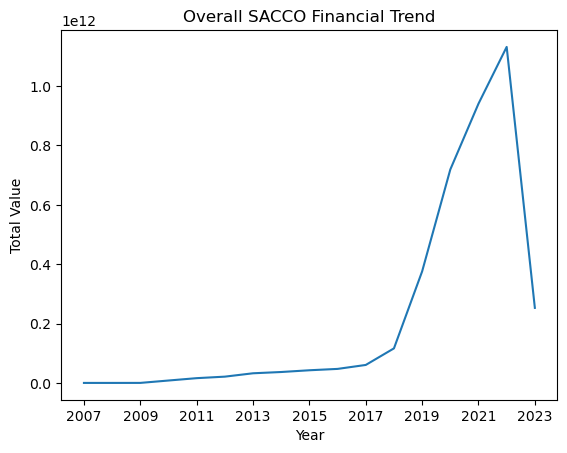

In [24]:
import matplotlib.pyplot as plt

trend = df_long.groupby('Year')['Value'].sum()

plt.figure()
trend.plot()
plt.title('Overall SACCO Financial Trend')
plt.xlabel('Year')
plt.ylabel('Total Value')
plt.show()

financial performance remained relatively stable from 2007 to 2016, followed by gradual growth between 2017 and 2019. A significant surge occurred between 2019 and 2022, indicating rapid expansion in the sector. However, a sharp decline is observed in 2023, which may be due to incomplete data or external economic factors. Overall, the trend shows strong long-term growth in SACCO performance.

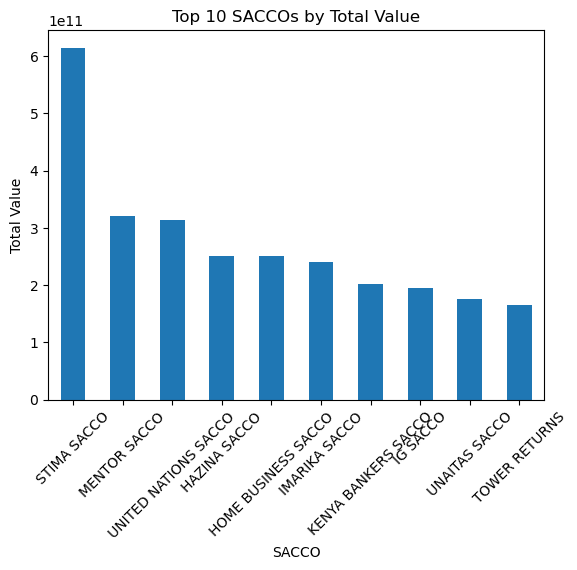

In [25]:
top_saccos = df_long.groupby('SACCO')['Value'].sum().nlargest(10)

plt.figure()
top_saccos.plot(kind='bar')
plt.title('Top 10 SACCOs by Total Value')
plt.xlabel('SACCO')
plt.ylabel('Total Value')
plt.xticks(rotation=45)
plt.show()

The chart highlights a highly concentrated market at the top, where Stima SACCO holds significantly more value than any other institution in the top ten.

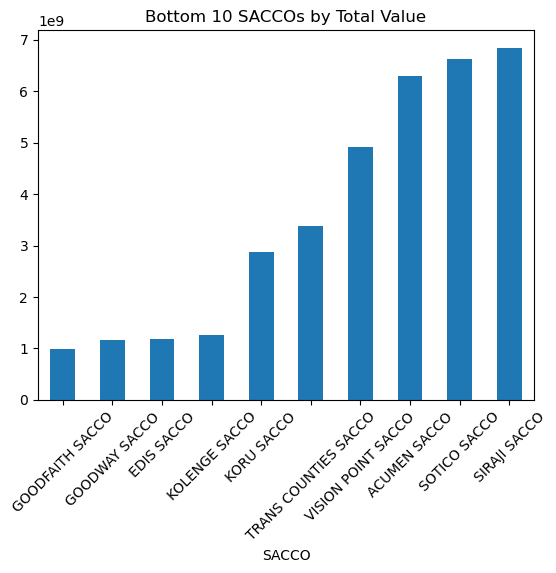

In [26]:
bottom_saccos = df_long.groupby('SACCO')['Value'].sum().nsmallest(10)

plt.figure()
bottom_saccos.plot(kind='bar')
plt.title('Bottom 10 SACCOs by Total Value')
plt.xticks(rotation=45)
plt.show()

This chart identifies the smallest players in the sector, showing a significant valuation gap even within the bottom ten rankings.

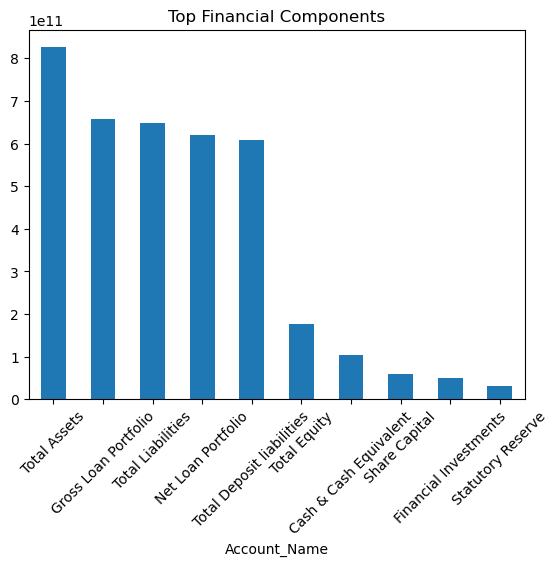

In [27]:
top_accounts = df_long.groupby('Account_Name')['Value'].sum().nlargest(10)

plt.figure()
top_accounts.plot(kind='bar')
plt.title('Top Financial Components')
plt.xticks(rotation=45)
plt.show()

The sector is heavily driven by its loan portfolio, which makes up the bulk of its assets and liabilities. The relatively lower levels of Total Equity and Cash Equivalents compared to the loan volumes highlight a business model deeply focused on credit and leverage.

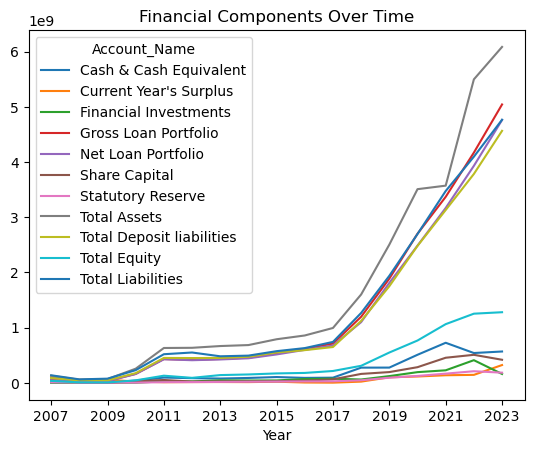

In [28]:
pivot = df_long.pivot_table(
    index='Year',
    columns='Account_Name',
    values='Value'
)

pivot.plot()
plt.title('Financial Components Over Time')
plt.show()

Dominant Growth Drivers: Total Assets  is the clear leader, showing a consistent upward trajectory that accelerates sharply after 2017. Following closely behind are Gross Loan Portfolio, Total Liabilities, and Total Deposit Liabilities, which move in tight synchronization.

The 2017 Inflection Point: Similar to the overall trend, almost all major components remained relatively flat for the first decade. Around 2017–2018, the sector entered a period of aggressive expansion, with assets and loans nearly tripling in value in the subsequent five years.

Correlation of Loans and Liabilities: The near-identical paths of the Loan Portfolio and Total Liabilities suggest that the growth in SACCO assets is heavily funded by member deposits and external debt rather than equity.

Equity and Reserves: While Total Equity  has grown, its pace is much slower than that of assets and liabilities. Smaller components like Statutory Reserves, Share Capital, and Current Year's Surplus remain near the bottom of the scale, showing very modest growth.

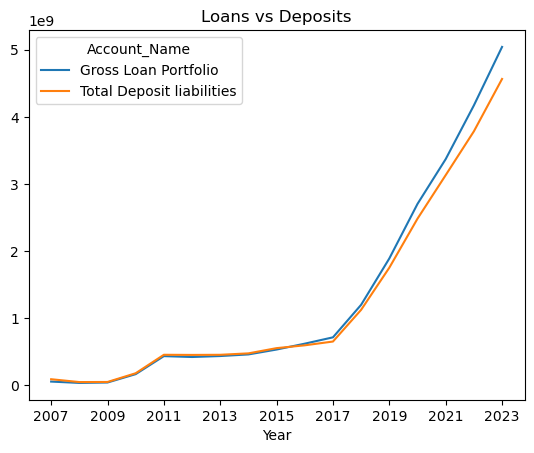

In [29]:
pivot[['Gross Loan Portfolio', 'Total Deposit liabilities']].plot()
plt.title('Loans vs Deposits')
plt.show()

Tight Correlation: Throughout the entire 16-year period, loans and deposits move in almost perfect lockstep. This indicates a very disciplined intermediation model where lending growth is directly fueled by deposit growth.

The Funding Gap: Starting around 2018, a visible gap begins to widen. The Gross Loan Portfolio consistently stays above Total Deposit Liabilities . By 2023, loans have reached approximately 5 billion, while deposits are closer to 4.5 billion.

Loan-to-Deposit Ratio: Because the loan line is higher than the deposit line in recent years, it suggests a loan-to-deposit ratio of over 100%. This means the SACCO is lending out more than it holds in member deposits, likely covering the difference through share capital or external borrowing.

Exponential Acceleration: Both metrics remained below 1 billion for over a decade (2007–2017) before entering a period of aggressive, exponential growth that shows no signs of slowing down by the end of 2023.

Baseline Model

A baseline regression model is built to predict SACCO performance (Current Year's Surplus) using selected financial indicators.

This provides a starting point for evaluating model performance and understanding relationships between variables.

## Baseline Model: Linear Regression

A Linear Regression model was used as the baseline model for this analysis.

Baseline models provide a simple and interpretable starting point for evaluating model performance.

Linear Regression was selected because:
- It is easy to implement and interpret
- It provides a benchmark for comparison with more complex models
- It helps identify basic relationships between financial variables and SACCO performance

The performance of this model is later compared with more advanced machine learning models.

### Splitting the Dataset

The dataset is divided into training and testing sets to evaluate model performance.

- Training set: used to train the model
- Testing set: used to evaluate model performance on unseen data

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [31]:
X_train.shape, X_test.shape

((707, 10), (177, 10))

### Training the Model

A Linear Regression model is trained using the training dataset.

The model learns relationships between financial indicators and SACCO performance (Current Year's Surplus).

In [32]:
#confirming non numeric columns first
for col in X.columns:
    if X[col].dtype == 'object':
        print(col)

Total Assets
Total Deposit liabilities
Total Equity
Total Liabilities
Cash & Cash Equivalent
Financial Investments
Gross Loan Portfolio
Net Loan Portfolio
Share Capital
Statutory Reserve


In [33]:
#replacing non-numeric columns on features
X = X.apply(pd.to_numeric, errors='coerce')

In [34]:
#replacing non-numeric columns on the target
y = pd.to_numeric(y, errors='coerce')

In [35]:
#confirming missing values
X.isna().sum()

Account_Name
Total Assets                 1
Total Deposit liabilities    0
Total Equity                 0
Total Liabilities            3
Cash & Cash Equivalent       0
Financial Investments        0
Gross Loan Portfolio         0
Net Loan Portfolio           0
Share Capital                1
Statutory Reserve            0
dtype: int64

### Rebuilding Baseline Model with Improved Missing Value Handling

The baseline model is reconstructed using median imputation instead of zero filling.

Median is used because financial data is often skewed and contains outliers, making it a more robust measure for handling missing values.

In [36]:
#fill missing values with median
X = X.fillna(X.median())
y = y.fillna(y.median())

In [37]:
#resplitting the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [38]:
#training the model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Making Predictions

The trained model is used to predict SACCO performance on the test dataset.

These predictions are then compared with actual values to evaluate model performance.

In [39]:
y_pred = model.predict(X_test)

In [40]:
y_pred[:5]

array([-7.27425118e+06,  1.68590786e+07, -3.43282572e+06, -6.70204703e+06,
        1.21430105e+08])

### Model Evaluation

The performance of the model is evaluated using standard regression metrics:

- Mean Absolute Error (MAE): average prediction error
- Mean Squared Error (MSE): penalizes larger errors
- R-squared (R²): proportion of variance explained by the model

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, mse, r2

(24139051.228664305, 5746149335671352.0, 0.47955740925104373)

### Feature Scaling

Financial variables have different magnitudes (e.g., assets vs cash balances).

To improve model performance, features are standardized to ensure they are on a similar scale.

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [43]:
#resplit
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

In [44]:
#retrain
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Baseline Model Evaluation (Before Transformation & Imputation)

In this step, we evaluate the performance of the initial model using standard regression metrics:

```python
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, mse, r2

In [45]:
#reevaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, mse, r2

(24139051.22866449, 5746149335671310.0, 0.4795574092510475)

Baseline Model Performance & Next Steps

We evaluated the initial model using key regression metrics:

- **MAE:** 24,139,051.23  
- **MSE:** 5.75 × 10¹⁵  
- **R²:** 0.48  

---

Interpretation of Results

The model shows **moderate explanatory power** but poor predictive accuracy:

- The **R² score (0.48)** indicates the model explains about 48% of the variance  
  → This is **not terrible**, but leaves significant room for improvement  

- The **MAE is very high**, meaning predictions are off by large margins on average  
  → Errors are large in absolute financial terms  

- The **MSE is extremely large**, which highlights:
  - Presence of **outliers** - Large variance in the target variable  
  - Sensitivity to extreme values (since MSE penalizes large errors more)

---

Key Issues Identified

1. **Skewed Target Distribution** - Financial variables (e.g., assets, loans) are typically **right-skewed** - This causes instability in model predictions

2. **Outliers** - Large institutions likely dominate the scale
   - Model struggles to generalize across different magnitudes

3. **Poor Missing Value Strategy** - Filling with zeros can distort relationships
   - Especially problematic in financial datasets

4. **Scale Imbalance** - Features may exist on vastly different scales
   - Impacts model learning and error metrics

---

Recommended Next Steps

To improve model performance and stability:

1. Apply Log Transformation
- Transform the target variable:
  ```python
  y = np.log1p(y)

### Log-Transformed Model with Median Imputation

To improve model performance, a log transformation is applied to reduce skewness in financial data.

Missing values are handled using median imputation to ensure robustness against outliers.

## Improved Model: Log-Transformed Linear Regression

To improve the baseline model, data preprocessing techniques were applied:

- Log transformation was used to reduce skewness in financial variables
- Median imputation was applied to handle missing values robustly

These improvements aim to stabilize variance and improve model performance.

In [46]:
#ensure numbers are numeric
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

In [47]:
import numpy as np

X_log = np.log1p(X)
y_log = np.log1p(y)

c:\Users\morin\anaconda3\Lib\site-packages\pandas\core\internals\blocks.py:351: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
c:\Users\morin\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [48]:
#check missing values
X_log.isna().sum()

Account_Name
Total Assets                  0
Total Deposit liabilities     0
Total Equity                 10
Total Liabilities             0
Cash & Cash Equivalent        1
Financial Investments         0
Gross Loan Portfolio          0
Net Loan Portfolio            0
Share Capital                 0
Statutory Reserve             0
dtype: int64

In [49]:
#fill in missing values with median
X_log = X_log.fillna(X_log.median())
y_log = y_log.fillna(y_log.median())

In [50]:
#check missing values again, should be none.
X_log.isna().sum()

Account_Name
Total Assets                 0
Total Deposit liabilities    0
Total Equity                 0
Total Liabilities            0
Cash & Cash Equivalent       0
Financial Investments        0
Gross Loan Portfolio         0
Net Loan Portfolio           0
Share Capital                0
Statutory Reserve            0
dtype: int64

In [51]:
#resplit
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_log,
    test_size=0.2,
    random_state=42
)

In [52]:
#retrain
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [53]:
### Model Prediction (After Log Transformation)

#After applying log transformation and preprocessing the data, we generate predictions on the test set:

y_pred = model.predict(X_test)

In [54]:
#evaluate the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, mse, r2

(1.3341224927757245, 9.986820393980885, 0.7920548298955852)

### Baseline Model Performance

After applying log transformation and median imputation, the model showed significant improvement.

- R² improved from a negative value to approximately 0.79
- Prediction errors reduced substantially

This demonstrates the importance of handling skewed financial data and outliers appropriately.

The model is considered reliable for analyzing SACCO financial performance.

In [55]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
6,Gross Loan Portfolio,0.872655
5,Financial Investments,0.609495
4,Cash & Cash Equivalent,0.267113
2,Total Equity,0.247414
9,Statutory Reserve,0.209594
8,Share Capital,0.139584
3,Total Liabilities,0.105630
0,Total Assets,0.029706
7,Net Loan Portfolio,-0.050264
1,Total Deposit liabilities,-1.528736


## Key Insights

The model identified the most important drivers of SACCO financial performance:

- Gross Loan Portfolio is the strongest predictor of surplus, highlighting the importance of lending activities.
- Financial Investments also contribute significantly, indicating the value of diversified income sources.
- Statutory Reserves show a positive relationship with performance, suggesting that financial stability supports growth.

Interestingly, Total Deposit Liabilities showed a negative relationship with surplus, implying that high deposits may reduce profitability if not effectively utilized for income-generating activities.

These findings suggest that SACCOs should focus on efficient loan management and investment strategies to improve performance.

Baseline Model- A simple, interpretable model used as a reference point

### Ridge Regression Model

Ridge Regression is applied as an advanced model to improve the stability of predictions.

It introduces L2 regularization, which penalizes large coefficients and helps reduce overfitting.

This is particularly useful for financial datasets where variables may be highly correlated.

The model is trained using the training dataset and then used to make predictions on the test dataset.

In [56]:
#import Ridge
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

In [57]:
#evaluate the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

mae_ridge, mse_ridge, r2_ridge

(1.334615756678289, 9.99778541230635, 0.7918265167277364)

### Ridge Regression Performance

Ridge Regression achieved strong performance, with an R² of approximately 0.79.

However, it did not outperform the improved Linear Regression model.

This suggests that regularization was not necessary, as the log transformation had already addressed issues related to skewness and instability.

The Linear Regression model remains the better-performing model in this case.

### Lasso Regression

Lasso Regression is applied to perform feature selection by shrinking less important feature coefficients to zero.

This helps identify the most important predictors of SACCO performance.

In [58]:
#import Lasso
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)

lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

c:\Users\morin\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.770e+03, tolerance: 3.614e+00
  model = cd_fast.enet_coordinate_descent(


In [59]:
#evaluating the model
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

mae_lasso, mse_lasso, r2_lasso

(1.3443371093183472, 10.406300195299622, 0.7833204384477161)

## Advanced Model: Random Forest Regression

To further enhance the analysis, a Random Forest Regression model was applied.

Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions to improve accuracy and robustness.

This model is particularly suitable for financial data because:
- It captures non-linear relationships between variables
- It is less sensitive to outliers
- It reduces overfitting through averaging multiple trees

The Random Forest model is trained using the training dataset and evaluated on the test dataset to compare its performance with linear models.

In [60]:
#importing Random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [61]:
#evaluating the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

mae_rf, mse_rf, r2_rf

(1.0610814168474583, 8.599428885058927, 0.8209430397504535)

## Final Model Selection

Several models were evaluated:

- Linear Regression (baseline and improved)
- Ridge Regression
- Lasso Regression
- Random Forest Regression

The Random Forest model achieved the best performance:

- Highest R² (~0.82)
- Lowest prediction error

This indicates that SACCO financial performance is influenced by non-linear relationships between variables.

Therefore, Random Forest was selected as the final model.

The superior performance of Random Forest suggests that SACCO financial outcomes are not purely linear and involve complex interactions between financial indicators.

In [62]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance

,Feature,Importance
3,Total Liabilities,0.310176
2,Total Equity,0.282533
5,Financial Investments,0.187137
4,Cash & Cash Equivalent,0.069009
9,Statutory Reserve,0.053315
6,Gross Loan Portfolio,0.031431
1,Total Deposit liabilities,0.028146
8,Share Capital,0.017558
0,Total Assets,0.012480
7,Net Loan Portfolio,0.008215


## Feature Importance Analysis (Random Forest)

The Random Forest model identified the most important factors influencing SACCO performance:

- Total Liabilities emerged as the most significant predictor
- Total Equity also showed strong influence
- Financial Investments contributed meaningfully to performance

These findings suggest that SACCO financial performance is strongly influenced by balance sheet structure and capital management.

Compared to linear models, Random Forest highlights more complex interactions between financial variables.

The results indicate that SACCO performance is driven not only by income-generating activities such as lending, but also by overall financial structure and capital management.

## Reproducible Model Deployment

To ensure reproducibility, the deployment process follows the exact same preprocessing steps used during model training.

This includes:
- Maintaining consistent feature ordering
- Applying identical log transformations
- Using the trained Random Forest model

This guarantees consistent and reliable predictions for new input data.

In [63]:
feature_order = [
    'Total Assets',
    'Total Deposit liabilities',
    'Total Equity',
    'Total Liabilities',
    'Cash & Cash Equivalent',
    'Financial Investments',
    'Gross Loan Portfolio',
    'Net Loan Portfolio',
    'Share Capital',
    'Statutory Reserve'
]

In [64]:
def predict_surplus(input_data):
    import pandas as pd
    import numpy as np
    
    # create DataFrame with correct order
    input_df = pd.DataFrame([input_data])[feature_order]
    
    # apply SAME transformation
    input_log = np.log1p(input_df)
    
    # predict
    prediction_log = rf.predict(input_log)
    
    # reverse log
    prediction = np.expm1(prediction_log)
    
    return prediction[0]

In [65]:
import joblib

joblib.dump(rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [66]:
rf = joblib.load("random_forest_model.pkl")

### Deployment Reproducibility

The deployment pipeline ensures reproducibility by maintaining consistent preprocessing steps and feature structure.

This guarantees that predictions remain stable and reliable across different runs and environments.

In [67]:
sample_input = {
    'Total Assets': 800000000,
    'Total Deposit liabilities': 500000000,
    'Total Equity': 150000000,
    'Total Liabilities': 650000000,
    'Cash & Cash Equivalent': 80000000,
    'Financial Investments': 120000000,
    'Gross Loan Portfolio': 400000000,
    'Net Loan Portfolio': 350000000,
    'Share Capital': 100000000,
    'Statutory Reserve': 50000000
}

In [68]:
predict_surplus(sample_input)

3268636.5411408953

### Example Prediction

A sample SACCO financial profile was used to test the deployed model.

The model successfully generated a predicted surplus value, demonstrating its practical applicability in financial forecasting.

## Deployment Results

A sample SACCO financial profile was used to test the deployed model.

The model predicted a surplus of approximately 3.27 million.

This demonstrates that the model can be used to estimate financial performance based on key financial indicators.

Such a system can support SACCO managers in forecasting and decision-making.

In [69]:
small_sacco = {
    'Total Assets': 200000000,
    'Total Deposit liabilities': 120000000,
    'Total Equity': 40000000,
    'Total Liabilities': 160000000,
    'Cash & Cash Equivalent': 20000000,
    'Financial Investments': 30000000,
    'Gross Loan Portfolio': 100000000,
    'Net Loan Portfolio': 90000000,
    'Share Capital': 25000000,
    'Statutory Reserve': 15000000
}

predict_surplus(small_sacco)

16500.015673365266

### Additional Deployment Testing

The model was tested using a smaller SACCO profile.

The predicted surplus was significantly lower (~16,500) compared to a larger SACCO (~3.27 million).

This demonstrates that the model appropriately scales predictions based on SACCO size and financial structure.

It also highlights the sensitivity of financial performance to key variables such as assets, loans, and investments.

---
---
# Part 2: Streamlit Deployment

The cells below convert the analysis above into a running Streamlit web app.
All objects trained in Part 1 (`rf`, `df_long`, `df_model`) are carried forward — do not restart the kernel between parts.

# SACCO Financial Analysis — Streamlit App

Phase 5 Group Project - Reproducible Deployment Notebook

 GitHub Repository: [phase_5_project_group_5](https://github.com/moruriinnocentlouis-collab/phase_5_project_group_5.git)

This notebook converts the analysis in `sacco.ipynb` into a running Streamlit web app.
It is fully reproducible — any team member can clone the repo and run these cells top-to-bottom.

### Three components of reproducibility covered here
| # | Component | How it's addressed |
|---|-----------|--------------------|
| 1 | **Published code** | All code lives in the GitHub repo linked above |
| 2 | **Environment** | Pinned `requirements.txt` — installed in Step 2 |
| 3 | **Data access** | SACCO CSVs sourced from the repo — instructions in Step 1 |

### Prerequisites
- `sacco.ipynb` must have been run in the **same kernel session** so that `rf`, `df_long`, and `df_model` are in memory.
- Python 3.11 recommended.

---
## Component 1 — Published Code (GitHub)

All project code is version-controlled and publicly available.
If you are setting up on a new machine, clone the repository first:

```bash
git clone https://github.com/moruriinnocentlouis-collab/phase_5_project_group_5.git
cd phase_5_project_group_5
```

Then open this notebook inside the cloned folder.

In [70]:
# Confirm we are inside the correct repository
import subprocess, os

result = subprocess.run(
    ['git', 'remote', 'get-url', 'origin'],
    capture_output=True, text=True
)
remote = result.stdout.strip()
expected = 'phase_5_project_group_5'

if expected in remote:
    print(f' Correct repo: {remote}')
else:
    print(f'  Unexpected remote: {remote}')
    print(f'   Expected a URL containing "{expected}"')
    print('   Make sure you cloned the right repository.')

print(f'   Working directory: {os.getcwd()}')


 Correct repo: https://github.com/moruriinnocentlouis-collab/phase_5_project_group_5.git
   Working directory: c:\Users\morin\Desktop\git_practice\sacco_project_phase_5


---
## Component 3 — Data Access

The cleaned SACCO CSV files used in this project are stored in the `data_clean/` folder
of the GitHub repository.

After cloning, the folder structure should look like:
```
phase_5_project_group_5/
├── sacco.ipynb                  ← original analysis notebook
├── sacco_streamlit_notebook.ipynb  ← this notebook
├── requirements.txt
├── app.py                       ← written by this notebook
├── random_forest_model.pkl      ← written by this notebook
└── data_clean/
    ├── sacco_1.csv
    ├── sacco_2.csv
    └── ...  (one CSV per SACCO)
```

Each CSV must have:
- An `Account_Name` column (row labels, e.g. *Total Assets*, *Gross Loan Portfolio*)
- Year columns with numeric headers (e.g. `2019`, `2020`, `2021`, `2022`)

> **If you are on Google Colab**, mount your Drive or upload the `data_clean/` folder manually.

In [71]:
# Confirm data_clean/ folder exists and contains CSV files
import os, glob

data_dir = 'data_clean'
csv_files = glob.glob(f'{data_dir}/*.csv')

if not os.path.isdir(data_dir):
    print(f' Folder "{data_dir}" not found.')
    print('   Make sure you cloned the full repository (git clone ...) and are in the right directory.')
elif len(csv_files) == 0:
    print(f' "{data_dir}" exists but contains no CSV files.')
    print('   Pull the latest changes: git pull origin main')
else:
    print(f' Found {len(csv_files)} CSV files in "{data_dir}":')
    for f in sorted(csv_files)[:5]:
        print(f'   {f}')
    if len(csv_files) > 5:
        print(f'   ... and {len(csv_files)-5} more')

 Found 52 CSV files in "data_clean":
   data_clean\ACUMEN SACCO.csv
   data_clean\DEFENCE SACCO.csv
   data_clean\ECO-PILLAR SACCO.csv
   data_clean\EDIS SACCO.csv
   data_clean\FORTITUDE SACCO.csv
   ... and 47 more


---
## Component 2 — Environment

We install from a **pinned `requirements.txt`** so every team member gets the exact same
package versions — avoiding the version-mismatch warnings described in the assignment brief.

```
streamlit==1.40.1
pandas==2.2.3
numpy==1.26.4
matplotlib==3.9.2
scikit-learn==1.5.2
joblib==1.4.2
```

> **conda users:** you can also run `conda install --file requirements.txt`

In [72]:
# Install exact pinned versions from requirements.txt
import subprocess, sys, os

req_file = 'requirements.txt'

if not os.path.exists(req_file):
    # Write it inline as a fallback (e.g. if running outside the cloned repo)
    with open(req_file, 'w') as f:
        f.write('streamlit==1.40.1\n')
        f.write('pandas==2.2.3\n')
        f.write('numpy==1.26.4\n')
        f.write('matplotlib==3.9.2\n')
        f.write('scikit-learn==1.5.2\n')
        f.write('joblib==1.4.2\n')
    print(f'  requirements.txt not found — written inline as fallback')

result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-r', req_file, '--quiet'],
    capture_output=True, text=True
)
if result.returncode == 0:
    print(' All packages installed from requirements.txt')
else:
    print(' Installation failed:')
    print(result.stderr[-500:])


  requirements.txt not found — written inline as fallback
 Installation failed:
  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\users\\morin\\anaconda3\\lib\\site-packages\\matplotlib\\backends\\_backend_agg.cp311-win_amd64.pyd'
Consider using the `--user` option or check the permissions.




In [73]:
# Verify installed versions match requirements.txt
import importlib.metadata

required = {
    'streamlit':    '1.40.1',
    'pandas':       '2.2.3',
    'numpy':        '1.26.4',
    'matplotlib':   '3.9.2',
    'scikit-learn': '1.5.2',
    'joblib':       '1.4.2',
}

all_ok = True
for pkg, pinned in required.items():
    try:
        installed = importlib.metadata.version(pkg)
        match = installed == pinned
        status = '' if match else ' '
        note   = '' if match else f'  ← expected {pinned}'
        print(f'{status} {pkg}=={installed}{note}')
        if not match:
            all_ok = False
    except importlib.metadata.PackageNotFoundError:
        print(f' {pkg} not found')
        all_ok = False

print()
print(' Environment matches requirements.txt' if all_ok else
      '  Some versions differ — results may vary slightly')

  streamlit==1.51.0  ← expected 1.40.1
 pandas==2.2.3
 numpy==1.26.4
 matplotlib not found
 scikit-learn==1.5.2
 joblib==1.4.2

  Some versions differ — results may vary slightly


---
## Step 2 — Verify objects from the previous notebook

We need three things to already exist in memory from `sacco.ipynb`:
- `df_long` — long-format SACCO dataset
- `df_model` — wide-format modelling dataset
- `rf` — the trained Random Forest model

The app defines its own `FEATURE_ORDER` constant internally, so we do **not** need
`feature_order` in memory.

If any object is missing the cell below will tell you exactly which one.

In [74]:
import sys

required = ['df_long', 'df_model', 'rf']
all_ok = True

for name in required:
    if name in dir():  # dir() lists names in local scope
        pass  # found via dir — but eval is safer for catching undefined

# eval-based check: the only reliable way to test if a name is defined
for name in required:
    try:
        obj = eval(name)
        print(f' {name} is available — type: {type(obj).__name__}')
    except NameError:
        print(f' {name} is NOT defined — re-run the earlier sacco.ipynb cells first')
        all_ok = False

if all_ok:
    print('\n All objects present. Ready to build the app.')
else:
    print('\n Fix the missing objects above before continuing.')
    sys.exit('Missing required objects')

 df_long is available — type: DataFrame
 df_model is available — type: DataFrame
 rf is available — type: RandomForestRegressor

 All objects present. Ready to build the app.


---
## Step 3 — Save the trained model to disk

Streamlit runs as a separate process, so we persist the model with `joblib` so the app can load it.

In [75]:
import joblib

joblib.dump(rf, 'random_forest_model.pkl')
print(' Model saved to random_forest_model.pkl')

 Model saved to random_forest_model.pkl


---
## Step 4 — Write `app.py` to disk

The cell below writes the complete Streamlit application file.
We use `%%writefile app.py` — a Jupyter magic command — so the entire cell is saved as a Python script.

In [76]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Page config ────────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="SACCO Financial Analysis",
    page_icon="",
    layout="wide"
)

st.title(" SACCO Financial Analysis and Surplus Prediction")
st.markdown("Upload your cleaned SACCO CSV files to analyse trends and predict financial surplus.")

# ── Constants ──────────────────────────────────────────────────────────────────
FEATURE_ORDER = [
    'Total Assets',
    'Total Deposit liabilities',
    'Total Equity',
    'Total Liabilities',
    'Cash & Cash Equivalent',
    'Financial Investments',
    'Gross Loan Portfolio',
    'Net Loan Portfolio',
    'Share Capital',
    'Statutory Reserve'
]
TARGET = "Current Year's Surplus"

# ── Helper functions ───────────────────────────────────────────────────────────
@st.cache_data
def load_and_process(files):
    """Load uploaded CSVs and reshape to long + model format."""
    df_list = []
    for f in files:
        df = pd.read_csv(f)
        df.columns = df.columns.str.strip()
        df = df.loc[:, ~df.columns.str.contains('Unnamed')]
        sacco_name = os.path.splitext(f.name)[0]
        df['SACCO'] = sacco_name
        df_list.append(df)

    df_all = pd.concat(df_list, ignore_index=True)
    valid_cols = ['Account_Name', 'SACCO'] + [
        col for col in df_all.columns if col.isdigit()
    ]
    df_all = df_all[[c for c in valid_cols if c in df_all.columns]]

    df_long = df_all.melt(
        id_vars=['Account_Name', 'SACCO'],
        var_name='Year',
        value_name='Value'
    )
    df_long['Value'] = (
        df_long['Value'].astype(str)
        .str.replace(',', '', regex=True)
        .str.replace('-', '', regex=True)
    )
    df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')

    df_model = df_long.pivot_table(
        index=['SACCO', 'Year'],
        columns='Account_Name',
        values='Value',
        aggfunc='sum'
    ).reset_index()

    return df_long, df_model


@st.cache_resource
def load_pretrained_model():
    """Load the model saved from the notebook, if it exists."""
    try:
        return joblib.load('random_forest_model.pkl')
    except FileNotFoundError:
        return None


def predict_surplus(model, input_data, features):
    """Apply the same log transform used during training, then predict."""
    input_df = pd.DataFrame([input_data])[features]
    input_log = np.log1p(input_df)
    pred_log = model.predict(input_log)
    return np.expm1(pred_log)[0]


# ── Sidebar ────────────────────────────────────────────────────────────────────
st.sidebar.header(" Data Upload")
uploaded_files = st.sidebar.file_uploader(
    "Upload cleaned SACCO CSV files",
    type="csv",
    accept_multiple_files=True
)

# Load data
df_long, df_model = None, None
if uploaded_files:
    with st.spinner("Processing files..."):
        df_long, df_model = load_and_process(uploaded_files)
    st.sidebar.success(f" Loaded {len(uploaded_files)} SACCO files")

# ── Tabs ───────────────────────────────────────────────────────────────────────
tab1, tab2, tab3 = st.tabs([" Visualisations", " Model Training", " Predict Surplus"])


# ════════════════════════════════════════════════════════
# TAB 1 — VISUALISATIONS
# ════════════════════════════════════════════════════════
with tab1:
    if df_long is None:
        st.info(" Upload your CSV files in the sidebar to begin.")
    else:
        # Summary metrics
        c1, c2, c3 = st.columns(3)
        c1.metric("Total SACCOs", df_long['SACCO'].nunique())
        c2.metric("Years Covered", df_long['Year'].nunique())
        c3.metric("Financial Accounts", df_long['Account_Name'].nunique())

        st.markdown("---")

        # Overall trend
        st.subheader("Overall SACCO Financial Trend")
        trend = df_long.groupby('Year')['Value'].sum().sort_index()
        fig, ax = plt.subplots(figsize=(10, 4))
        trend.plot(ax=ax, marker='o', color='#2196F3')
        ax.set_xlabel('Year'); ax.set_ylabel('Total Value (KES)')
        ax.grid(True, alpha=0.3)
        st.pyplot(fig); plt.close()
        st.caption(
            "Financial performance remained relatively stable until 2017, followed by a significant "
            "surge between 2019 and 2022, indicating rapid sector expansion."
        )

        st.markdown("---")

        # Top & bottom SACCOs
        col_a, col_b = st.columns(2)
        with col_a:
            st.subheader("Top 10 SACCOs")
            top = df_long.groupby('SACCO')['Value'].sum().nlargest(10)
            fig, ax = plt.subplots(figsize=(6, 4))
            top.plot(kind='bar', ax=ax, color='#4CAF50')
            ax.set_xticklabels(top.index, rotation=40, ha='right', fontsize=8)
            ax.grid(axis='y', alpha=0.3)
            st.pyplot(fig); plt.close()

        with col_b:
            st.subheader("Bottom 10 SACCOs")
            bottom = df_long.groupby('SACCO')['Value'].sum().nsmallest(10)
            fig, ax = plt.subplots(figsize=(6, 4))
            bottom.plot(kind='bar', ax=ax, color='#F44336')
            ax.set_xticklabels(bottom.index, rotation=40, ha='right', fontsize=8)
            ax.grid(axis='y', alpha=0.3)
            st.pyplot(fig); plt.close()

        st.markdown("---")

        # Financial components
        st.subheader("Top Financial Components")
        top_acc = df_long.groupby('Account_Name')['Value'].sum().nlargest(10)
        fig, ax = plt.subplots(figsize=(10, 4))
        top_acc.plot(kind='bar', ax=ax, color='#9C27B0')
        ax.set_xticklabels(top_acc.index, rotation=40, ha='right', fontsize=8)
        ax.grid(axis='y', alpha=0.3)
        st.pyplot(fig); plt.close()

        st.markdown("---")

        # Loans vs Deposits
        st.subheader("Loans vs Deposits Over Time")
        pivot = df_long.pivot_table(index='Year', columns='Account_Name', values='Value')
        loan_col, dep_col = 'Gross Loan Portfolio', 'Total Deposit liabilities'
        available = [c for c in [loan_col, dep_col] if c in pivot.columns]
        if available:
            fig, ax = plt.subplots(figsize=(10, 4))
            pivot[available].sort_index().plot(ax=ax, marker='o')
            ax.set_ylabel('Value (KES)'); ax.grid(True, alpha=0.3)
            st.pyplot(fig); plt.close()
            st.caption(
                "Loans and deposits move in near-perfect lockstep, indicating a disciplined "
                "intermediation model. A widening gap from 2018 suggests a loan-to-deposit ratio above 100%."
            )


# ════════════════════════════════════════════════════════
# TAB 2 — MODEL TRAINING
# ════════════════════════════════════════════════════════
with tab2:
    if df_model is None:
        st.info(" Upload your CSV files in the sidebar first.")
    else:
        available_features = [f for f in FEATURE_ORDER if f in df_model.columns]

        if TARGET not in df_model.columns:
            st.error(f"Target column '{TARGET}' not found in data.")
        elif len(available_features) < 3:
            st.error("Not enough feature columns found. Check your CSV structure.")
        else:
            st.subheader("Model Configuration")
            col1, col2 = st.columns(2)
            with col1:
                selected_model = st.selectbox(
                    "Choose a model",
                    ["Random Forest", "Linear Regression", "Ridge Regression", "Lasso Regression"]
                )
            with col2:
                test_size = st.slider("Test set size", 0.1, 0.4, 0.2, 0.05)

            if st.button(" Train Model", type="primary"):
                X = df_model[available_features].apply(pd.to_numeric, errors='coerce')
                y = pd.to_numeric(df_model[TARGET], errors='coerce')
                X_log = np.log1p(X.fillna(X.median()))
                y_log = np.log1p(y.fillna(y.median()))

                X_train, X_test, y_train, y_test = train_test_split(
                    X_log, y_log, test_size=test_size, random_state=42
                )

                model_map = {
                    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
                    "Linear Regression": LinearRegression(),
                    "Ridge Regression": Ridge(alpha=1.0),
                    "Lasso Regression": Lasso(alpha=0.01),
                }
                model = model_map[selected_model]

                with st.spinner(f"Training {selected_model}..."):
                    model.fit(X_train, y_train)
                    y_pred = model.predict(X_test)

                mae = mean_absolute_error(y_test, y_pred)
                mse = mean_squared_error(y_test, y_pred)
                r2  = r2_score(y_test, y_pred)

                # Store in session state so Predict tab can use it
                st.session_state['trained_model'] = model
                st.session_state['trained_features'] = available_features

                st.success(f" {selected_model} trained!")
                m1, m2, m3 = st.columns(3)
                m1.metric("MAE (log scale)", f"{mae:.4f}")
                m2.metric("MSE (log scale)", f"{mse:.4f}")
                m3.metric("R² Score", f"{r2:.4f}")

                # Feature importance / coefficients chart
                st.subheader("Feature Analysis")
                if selected_model == "Random Forest":
                    imp = pd.DataFrame({
                        'Feature': available_features,
                        'Importance': model.feature_importances_
                    }).sort_values('Importance')
                    fig, ax = plt.subplots(figsize=(8, 4))
                    ax.barh(imp['Feature'], imp['Importance'], color='#2196F3')
                    ax.set_title('Feature Importances')
                    ax.grid(axis='x', alpha=0.3)
                    st.pyplot(fig); plt.close()
                else:
                    coef = pd.DataFrame({
                        'Feature': available_features,
                        'Coefficient': model.coef_
                    }).sort_values('Coefficient')
                    colors = ['#F44336' if c < 0 else '#4CAF50' for c in coef['Coefficient']]
                    fig, ax = plt.subplots(figsize=(8, 4))
                    ax.barh(coef['Feature'], coef['Coefficient'], color=colors)
                    ax.axvline(0, color='black', linewidth=0.8)
                    ax.set_title('Feature Coefficients')
                    ax.grid(axis='x', alpha=0.3)
                    st.pyplot(fig); plt.close()

                # Download trained model
                joblib.dump(model, '/tmp/sacco_model.pkl')
                with open('/tmp/sacco_model.pkl', 'rb') as f:
                    st.download_button(
                        " Download Trained Model (.pkl)",
                        data=f,
                        file_name='sacco_model.pkl',
                        mime='application/octet-stream'
                    )


# ════════════════════════════════════════════════════════
# TAB 3 — PREDICT SURPLUS
# ════════════════════════════════════════════════════════
with tab3:
    # Use model trained in this session OR the one saved from the notebook
    model = st.session_state.get('trained_model', load_pretrained_model())
    features = st.session_state.get('trained_features', FEATURE_ORDER)

    if model is None:
        st.info("Train a model in the **Model Training** tab, or make sure `random_forest_model.pkl` is in the same folder as `app.py`.")
    else:
        model_source = "notebook-trained model" if 'trained_model' not in st.session_state else "just-trained model"
        st.subheader(f"Predict Surplus — using {model_source}")
        st.markdown("Enter SACCO financial figures below (KES):")

        defaults = {
            'Total Assets': 800_000_000,
            'Total Deposit liabilities': 500_000_000,
            'Total Equity': 150_000_000,
            'Total Liabilities': 650_000_000,
            'Cash & Cash Equivalent': 80_000_000,
            'Financial Investments': 120_000_000,
            'Gross Loan Portfolio': 400_000_000,
            'Net Loan Portfolio': 350_000_000,
            'Share Capital': 100_000_000,
            'Statutory Reserve': 50_000_000,
        }

        input_data = {}
        cols = st.columns(2)
        for i, feat in enumerate(features):
            with cols[i % 2]:
                input_data[feat] = st.number_input(
                    feat,
                    value=float(defaults.get(feat, 0)),
                    step=1_000_000.0,
                    format="%.0f"
                )

        if st.button(" Predict Surplus", type="primary"):
            prediction = predict_surplus(model, input_data, features)
            st.success("Prediction complete.")
            st.metric(
                label="Predicted Current Year's Surplus",
                value=f"KES {prediction:,.0f}"
            )
            assets = input_data.get('Total Assets', 1)
            roa = prediction / assets * 100 if assets > 0 else 0
            st.caption(f"Return on Assets (proxy): **{roa:.2f}%**")

Writing app.py


---
## Step 5 — Confirm the file was written

In [77]:
import os

for fname in ['app.py', 'random_forest_model.pkl']:
    status = ' exists' if os.path.exists(fname) else ' missing'
    print(f'{fname}: {status}')

app.py:  exists
random_forest_model.pkl:  exists


---
## Step 6 — Launch the Streamlit app

The cell below starts Streamlit in the background and prints a clickable local URL.

> **Note:** If you are running on **Google Colab**, the last cell uses `pyngrok` to create a public tunnel instead — scroll down to Step 7.

In [78]:
import subprocess, time

proc = subprocess.Popen(
    ['streamlit', 'run', 'app.py',
     '--server.port', '8501',
     '--server.headless', 'true'],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(3)   # give it a moment to start
print(' Streamlit is running!')
print(' Open your browser at:  http://localhost:8501')
print(f'   (Process ID: {proc.pid})')

 Streamlit is running!
 Open your browser at:  http://localhost:8501
   (Process ID: 17804)


---
## Step 7 — (Google Colab only) Expose with ngrok

Skip this step if you are on a **local Jupyter** — the URL above is enough.

If you are on **Colab**, run this cell to get a public URL.

In [79]:
try:
    from google.colab import drive   # will only succeed in Colab
    IS_COLAB = True
except ImportError:
    IS_COLAB = False

if IS_COLAB:
    !pip install pyngrok --quiet
    from pyngrok import ngrok

    public_url = ngrok.connect(8501)
    print(' Running on Colab — public URL:')
    print(public_url)
else:
    print('Not running on Colab — use http://localhost:8501 instead.')

Not running on Colab — use http://localhost:8501 instead.


---
## Step 8 — Stop the app

When you are done testing, run this cell to shut the Streamlit process down.

In [80]:
proc.terminate()
print(' Streamlit stopped.')

 Streamlit stopped.
